In [1]:
import os
from tensorflow.keras.models import load_model

MODEL_PATH = "mood_model.h5"

if os.path.exists(MODEL_PATH):
    print("✅ Found existing model, loading...")
    model = load_model(MODEL_PATH)
else:
    print("⚙️ No model found. Need to train a new one.")
    model = None  # We'll define later if not loaded


✅ Found existing model, loading...


In [2]:
# import os
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# # Paths
# train_dir = "FER-2013/train"
# test_dir  = "FER-2013/test"

# # Original FER classes in your folder structure presumably: 
# # ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

# # We want to map these to your 4 mood classes: {angry, happy, sad, neutral}
# # We decide a mapping, e.g.:
# mood_map = {
#     "angry": "angry",
#     "disgust": "neutral",   # map disgust → neutral or merge with angry if you want
#     "fear": "neutral",
#     "surprise": "neutral",
#     "happy": "happy",
#     "sad": "sad",
#     "neutral": "neutral"
# }

# # The set of final moods
# final_moods = ["angry", "happy", "sad", "neutral"]
# num_classes = len(final_moods)

# # Helper to map from original folder name to class index
# mood_to_index = {m: i for i, m in enumerate(final_moods)}

# def map_original_to_final(orig_class_name):
#     final = mood_map.get(orig_class_name, "neutral")
#     return mood_to_index[final]

# # Use Keras image_dataset_from_directory
# IMG_SIZE = (48, 48)  # FER images are 48×48

# def load_dataset(directory, batch_size=32, shuffle=True):
#     # First, load all classes, but we will remap labels
#     ds = tf.keras.preprocessing.image_dataset_from_directory(
#         directory,
#         labels="inferred",
#         label_mode="int",
#         image_size=IMG_SIZE,
#         color_mode="grayscale",
#         batch_size=batch_size,
#         shuffle=shuffle
#     )
#     # But currently ds yields label indices among the 7 original classes, we want to remap
#     class_names = ds.class_names  # e.g. ["angry", "disgust", ...]
#     print("Original classes:", class_names)

#     # Build a mapping array from original index → new index
#     orig_to_new = []
#     for orig in class_names:
#         new_idx = map_original_to_final(orig)
#         orig_to_new.append(new_idx)
#     orig_to_new = np.array(orig_to_new, dtype=np.int32)

#     def map_labels(images, labels):
#         # labels is tensor of original class indices
#         new_labels = tf.gather(orig_to_new, labels)
#         return images, new_labels

#     ds = ds.map(map_labels, num_parallel_calls=tf.data.AUTOTUNE)
#     return ds

# batch_size = 64
# train_ds = load_dataset(train_dir, batch_size=batch_size, shuffle=True)
# test_ds  = load_dataset(test_dir, batch_size=batch_size, shuffle=False)

# # Optionally, split some of train into validation
# val_split = 0.1
# train_size = tf.data.experimental.cardinality(train_ds).numpy()
# val_size = int(train_size * val_split)
# # you can do:
# val_ds = train_ds.take(val_size)
# train_ds = train_ds.skip(val_size)

# # Prefetch etc.
# AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
# val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
# test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)


In [3]:
# def build_model(input_shape=(48,48,1), num_classes=4):
#     model = models.Sequential()
#     model.add(layers.Conv2D(32, (3,3), activation='relu', padding="same", input_shape=input_shape))
#     model.add(layers.BatchNormalization())
#     model.add(layers.Conv2D(32, (3,3), activation='relu', padding="same"))
#     model.add(layers.BatchNormalization())
#     model.add(layers.MaxPooling2D((2,2)))
#     model.add(layers.Dropout(0.25))

#     model.add(layers.Conv2D(64, (3,3), activation='relu', padding="same"))
#     model.add(layers.BatchNormalization())
#     model.add(layers.Conv2D(64, (3,3), activation='relu', padding="same"))
#     model.add(layers.BatchNormalization())
#     model.add(layers.MaxPooling2D((2,2)))
#     model.add(layers.Dropout(0.25))

#     model.add(layers.Conv2D(128, (3,3), activation='relu', padding="same"))
#     model.add(layers.BatchNormalization())
#     model.add(layers.Conv2D(128, (3,3), activation='relu', padding="same"))
#     model.add(layers.BatchNormalization())
#     model.add(layers.MaxPooling2D((2,2)))
#     model.add(layers.Dropout(0.25))

#     model.add(layers.Flatten())
#     model.add(layers.Dense(256, activation="relu"))
#     model.add(layers.BatchNormalization())
#     model.add(layers.Dropout(0.5))
#     model.add(layers.Dense(num_classes, activation="softmax"))

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#         loss=tf.keras.losses.SparseCategoricalCrossentropy(),
#         metrics=["accuracy"]
#     )
#     return model

# model = build_model()
# model.summary()


In [4]:
# # 1️⃣ Compute class weights to handle class imbalance
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# # Extract y labels from train_ds
# y_train = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in train_ds.unbatch()])
# class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weights = dict(enumerate(class_weights))
# print("✅ Class Weights:", class_weights)

# # 2️⃣ Train with class weights
# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=50,
#     callbacks=[checkpoint, early, reduce_lr],
#     class_weight=class_weights
# )


In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# Paths
train_dir = "FER-2013/train"
test_dir  = "FER-2013/test"

# Map original FER classes → 4 moods
mood_map = {
    "angry": "angry",
    "disgust": "neutral",
    "fear": "neutral",
    "surprise": "neutral",
    "happy": "happy",
    "sad": "sad",
    "neutral": "neutral"
}

final_moods = ["angry", "happy", "sad", "neutral"]
num_classes = len(final_moods)
mood_to_index = {m: i for i, m in enumerate(final_moods)}

def map_original_to_final(orig_class_name):
    final = mood_map.get(orig_class_name, "neutral")
    return mood_to_index[final]

IMG_SIZE = (48, 48)

def load_dataset(directory, batch_size=32, shuffle=True):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        color_mode="grayscale",
        batch_size=batch_size,
        shuffle=shuffle
    )
    class_names = ds.class_names
    print("Original classes:", class_names)

    orig_to_new = np.array([map_original_to_final(c) for c in class_names], dtype=np.int32)

    def map_labels(images, labels):
        new_labels = tf.gather(orig_to_new, labels)
        return images, new_labels

    ds = ds.map(map_labels, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

batch_size = 64
train_ds = load_dataset(train_dir, batch_size=batch_size, shuffle=True)
test_ds  = load_dataset(test_dir, batch_size=batch_size, shuffle=False)

# Split train → val
val_split = 0.1
train_size = tf.data.experimental.cardinality(train_ds).numpy()
val_size = int(train_size * val_split)
val_ds = train_ds.take(val_size)
train_ds = train_ds.skip(val_size)

AUTOTUNE = tf.data.AUTOTUNE

# 🧹 STEP 1: Preprocess images (standardize + grayscale)
# 🧹 STEP 1: Preprocess images (standardize only)
def preprocess_image(img, label):
    img = tf.image.resize(img, [48, 48])              # ensure consistent size
    img = tf.image.per_image_standardization(img)     # normalize contrast and brightness
    return img, label


train_ds = train_ds.map(preprocess_image)
val_ds = val_ds.map(preprocess_image)
test_ds = test_ds.map(preprocess_image)

# 🌀 STEP 2: Add Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Optimize performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

# ⚙️ STEP 3: Define your CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 💾 STEP 4: Callbacks
checkpoint = ModelCheckpoint("mood_model.h5", monitor='val_accuracy', save_best_only=True, mode='max')
early = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5, min_lr=1e-5)

# ⚖️ STEP 5: Handle class imbalance
y_train = np.fromiter((y.numpy().item() for x, y in train_ds.unbatch()), dtype=np.int32)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("✅ Class Weights:", class_weights)

# 🚀 STEP 6: Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early, reduce_lr],
    class_weight=class_weights
)

# 📊 STEP 7: Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Test Accuracy: {test_acc:.3f}")
print(f"🧾 Test Loss: {test_loss:.3f}")


NotFoundError: Could not find directory FER-2013/train

In [ ]:
import mediapipe as mp
print(mp.__version__)

0.10.21


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []

for x, y in test_ds:
    preds = model.predict(x)
    
    # Handle y: either one-hot or integer
    if len(y.shape) > 1 and y.shape[1] > 1:  
        y_true.extend(np.argmax(y, axis=1))
    else:
        y_true.extend(y.numpy())
        
    y_pred.extend(np.argmax(preds, axis=1))

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=final_moods))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━

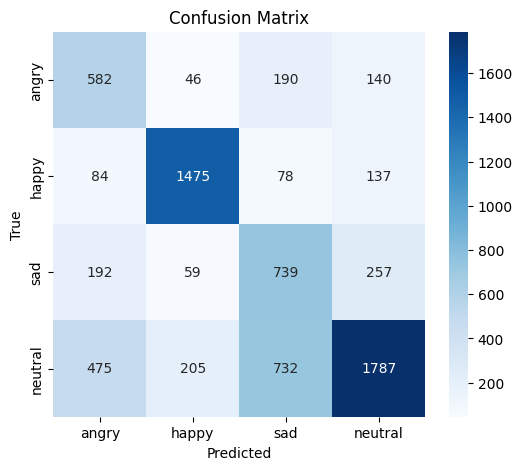

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_moods, yticklabels=final_moods)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.utils import class_weight
import numpy as np

y_train_labels = np.concatenate([y for x, y in train_ds], axis=0)
if len(y_train_labels.shape) > 1 and y_train_labels.shape[1] > 1:
    y_train_labels = np.argmax(y_train_labels, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights))


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early, reduce_lr],
    class_weight=class_weights
)


Epoch 1/50


405/405 ━━━━━━━━━━━━━━━━━━━━ 1681s 4s/step - accuracy: 0.7707 - loss: 0.6447 - val_accuracy: 0.7067 - val_loss: 0.7270 - learning_rate: 7.8125e-07
Epoch 2/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 93s 228ms/step - accuracy: 0.7722 - loss: 0.6347 - val_accuracy: 0.7053 - val_loss: 0.7315 - learning_rate: 7.8125e-07
Epoch 3/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 4999s 12s/step - accuracy: 0.7743 - loss: 0.6388 - val_accuracy: 0.7024 - val_loss: 0.7357 - learning_rate: 7.8125e-07
Epoch 4/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 116s 284ms/step - accuracy: 0.7737 - loss: 0.6332 - val_accuracy: 0.7003 - val_loss: 0.7382 - learning_rate: 7.8125e-07
Epoch 5/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 94s 230ms/step - accuracy: 0.7724 - loss: 0.6338 - val_accuracy: 0.6992 - val_loss: 0.7403 - learning_rate: 3.9062e-07
Epoch 6/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 130s 318ms/step - accuracy: 0.7761 - loss: 0.6257 - val_accuracy: 0.6982 - val_loss: 0.7467 - learning_rate: 3.9062e-07
Epoch 7/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 136s 334ms/step 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Test Accuracy: {test_acc:.3f}")
print(f"🧾 Test Loss: {test_loss:.3f}")


113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6530 - loss: 0.9010
✅ Test Accuracy: 0.694
🧾 Test Loss: 0.794


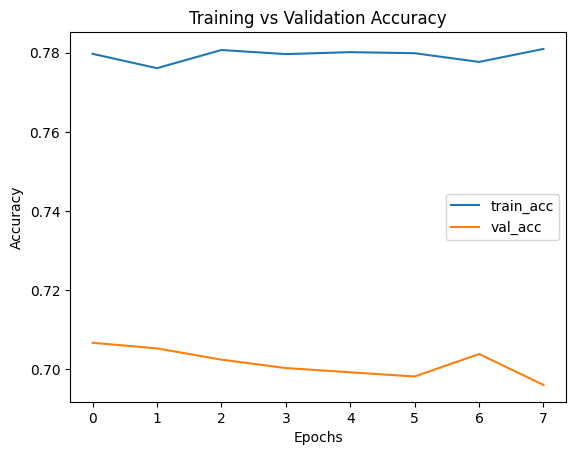

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━

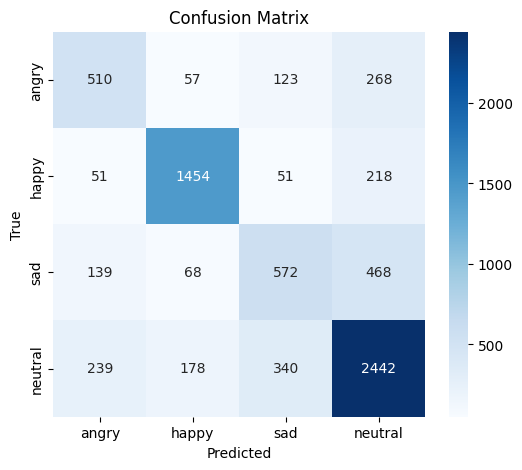

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []

for x, y in test_ds:
    preds = model.predict(x)
    y_true.extend(y.numpy())                         # true labels
    y_pred.extend(np.argmax(preds, axis=1))          # predicted labels

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=final_moods))

# Optional: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=final_moods, yticklabels=final_moods)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("mood_model.h5")
final_moods = ["angry", "happy", "sad", "neutral"]

# Setup MediaPipe Face Detection (or Face Mesh)
mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(min_detection_confidence=0.5)

# Optionally face mesh if you want landmarks
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False,
                                  max_num_faces=1,
                                  refine_landmarks=False,
                                  min_detection_confidence=0.5,
                                  min_tracking_confidence=0.5)

def preprocess_face(gray_roi):
    # gray_roi: 2D array, grayscale face crop
    img = cv2.resize(gray_roi, (48,48))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, -1)  # shape 48x48x1
    img = np.expand_dims(img, 0)   # batch dimension
    return img

cap = cv2.VideoCapture(0)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    det_res = face_detector.process(img_rgb)
    if det_res.detections:
        for det in det_res.detections:
            bbox = det.location_data.relative_bounding_box
            h, w, _ = frame.shape
            x1 = int(bbox.xmin * w)
            y1 = int(bbox.ymin * h)
            x2 = x1 + int(bbox.width * w)
            y2 = y1 + int(bbox.height * h)

            # Clip
            x1 = max(0, x1); y1 = max(0, y1)
            x2 = min(w, x2); y2 = min(h, y2)

            face = frame[y1:y2, x1:x2]
            if face.size == 0:
                continue
            face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
            inp = preprocess_face(face_gray)
            preds = model.predict(inp)
            class_id = np.argmax(preds[0])
            mood = final_moods[class_id]

            # Overlay
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(frame, mood, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

    cv2.imshow("Mood Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1

In [ ]:
import numpy as np
from collections import Counter

print("Class indices:", train_gen.class_indices)
print("Total training samples:", train_gen.samples)
print("Training class distribution:")
print(Counter(train_gen.classes))


Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Total training samples: 28709
Training class distribution:
Counter({3: 7215, 4: 4965, 5: 4830, 2: 4097, 0: 3995, 6: 3171, 1: 436})
